# Tier 5: Federated ML on Bloom-Encoded Features

**CSCI 575 | Privacy-Preserving Record Linkage**

Same FedAvg training as Tier 4, but the feature matrix is computed from Bloom-filter encodings (text fields, Dice similarity) and salted SHA-256 hashes (structured fields, equality). No plaintext PII crosses between parties. This is the first tier where the privacy claim genuinely holds.

Bloom encoding obfuscates plaintext without providing a formal privacy guarantee. A production PPRL system would pair it with DP-SGD.

### Glossary

- **Bloom filter:** A data structure that records membership of items via multiple hash functions. Two filters can be compared to estimate the overlap of their underlying sets without revealing the items themselves.
- **Salted SHA-256:** A cryptographic hash applied to a value prefixed with a shared random salt. Both parties hash the same plaintext to the same digest, but an attacker without the salt can't reverse common values via a dictionary attack.

In [1]:
import hashlib

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics         import f1_score

from utils import (
    FEATURE_NAMES,
    load_candidates, exact_match, normalize_digits, normalize_state,
    sigmoid, train_locally, fedavg,
    compute_metrics, print_metrics, save_metrics,
    plot_score_distribution,
    save_example_pair_predictions,
)

THRESHOLD = 0.50

# FedAvg parameters - identical to Tier 4
N_PARTIES     = 2
N_ROUNDS      = 100
LOCAL_EPOCHS  = 2
BATCH_SIZE    = 512
LEARNING_RATE = 0.1
RANDOM_SEED   = 42

## Privacy-Preserving Encoding

- **Bloom-filter encoding** (Schnell et al. 2009) for text fields. Each string becomes a 1000-bit bit-array via 20 hash positions per character bigram; pairs are compared by **Dice coefficient** on the bitstrings as a replacement for plaintext Jaro-Winkler.
- **Salted SHA-256 hashing** for structured fields (ZIP, state, phone). Each normalized value is hashed with a shared salt; parties compare hashes for equality, recovering the same `1.0 / 0.0` signal as plaintext equality without exchanging the raw values.

In [2]:
# Bloom-filter parameters (Schnell et al. 2009 defaults)
BLOOM_LENGTH     = 1000   # bits per filter
BLOOM_HASHES     = 20     # hash positions per q-gram
BLOOM_QGRAM_SIZE = 2      # q-gram size (bigrams)
SHARED_SALT      = 'pprl_2026_shared_salt'   


def bloom_encode(text):
    """One string -> BLOOM_LENGTH-bit Bloom filter via double hashing on bigrams."""
    bits = np.zeros(BLOOM_LENGTH, dtype=np.uint8)
    if not isinstance(text, str) or not text:
        return bits
    padded = f'${text.lower()}$'
    qgrams = [padded[i:i + BLOOM_QGRAM_SIZE] for i in range(len(padded) - BLOOM_QGRAM_SIZE + 1)]
    for qgram in qgrams:
        h1 = int(hashlib.md5(qgram.encode()).hexdigest(),  16)
        h2 = int(hashlib.sha1(qgram.encode()).hexdigest(), 16)
        for i in range(BLOOM_HASHES):
            bits[(h1 + i * h2) % BLOOM_LENGTH] = 1
    return bits


def bloom_similarity(series_a, series_b):
    """Dice coefficient on Bloom-encoded strings."""
    cache = {}
    def encode(value):
        if not isinstance(value, str) or not value:
            return np.zeros(BLOOM_LENGTH, dtype=np.uint8)
        if value not in cache:
            cache[value] = bloom_encode(value)
        return cache[value]

    scores = np.zeros(len(series_a), dtype=np.float64)
    for i, (value_a, value_b) in enumerate(zip(series_a, series_b)):
        bits_a, bits_b = encode(value_a), encode(value_b)
        total = int(bits_a.sum() + bits_b.sum())
        if total > 0:
            scores[i] = 2 * int((bits_a & bits_b).sum()) / total
    return pd.Series(scores, index=series_a.index)


def salted_hash(series, salt=SHARED_SALT):
    """SHA256 of each value prefixed by a shared salt. Empty values stay empty."""
    return series.fillna('').astype(str).apply(
        lambda v: hashlib.sha256((salt + v).encode()).hexdigest() if v else ''
    )


def build_bloom_feature_matrix(candidates):
    """8-column similarity matrix where no plaintext PII crosses between parties."""
    return pd.DataFrame({
        'first_name':     bloom_similarity(candidates['first_name_a'],     candidates['first_name_b']),
        'last_name':      bloom_similarity(candidates['last_name_a'],      candidates['last_name_b']),
        'street_address': bloom_similarity(candidates['street_address_a'], candidates['street_address_b']),
        'date_of_birth':  bloom_similarity(candidates['date_of_birth_a'],  candidates['date_of_birth_b']),
        'email':          bloom_similarity(candidates['email_a'],          candidates['email_b']),
        'zip_code':       exact_match(salted_hash(normalize_digits(candidates['zip_code_a'])), salted_hash(normalize_digits(candidates['zip_code_b']))),
        'state':          exact_match(salted_hash(normalize_state(candidates['state_a'])),     salted_hash(normalize_state(candidates['state_b']))),
        'phone':          exact_match(salted_hash(normalize_digits(candidates['phone_a'])),    salted_hash(normalize_digits(candidates['phone_b']))),
    })[FEATURE_NAMES]

## Load Data and Build Bloom Feature Matrix

`build_bloom_feature_matrix()` replaces the plaintext `build_feature_matrix()` from Tiers 1–4. Same 8-column shape, same `[0, 1]` range, but text fields use Dice on 1000-bit Bloom filters and structured fields use salted-hash equality.

In [3]:
candidates              = load_candidates()
field_similarity_scores = build_bloom_feature_matrix(candidates)

print(f'{len(candidates):,} candidate pairs  '
      f'({candidates["is_match"].sum():,} matches, '
      f'{(~candidates["is_match"]).sum():,} non-matches)')

500,000 candidate pairs  (50,000 matches, 450,000 non-matches)


## Split Across Federated Parties

Same split and partitioning logic as Tier 4.

In [4]:
labels = candidates['is_match'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    field_similarity_scores,
    labels,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=labels,
)

X_train_array = X_train.values.astype(np.float64)
y_train_array = y_train.values.astype(np.float64)
X_test_array  = X_test.values.astype(np.float64)
y_test_array  = y_test.values.astype(np.float64)

rng = np.random.default_rng(RANDOM_SEED)
shuffled_indices = rng.permutation(len(X_train_array))
party_splits     = np.array_split(shuffled_indices, N_PARTIES)

parties = [
    (X_train_array[split], y_train_array[split])
    for split in party_splits
]


## FedAvg Training

Identical loop to Tier 4: same logistic regression, same FedAvg weight averaging. Only the input feature matrix differs.

In [5]:
global_weights   = rng.normal(0, 0.01, len(FEATURE_NAMES))
global_intercept = 0.0

for round_number in range(1, N_ROUNDS + 1):
    local_results = [
        train_locally(party_X, party_y, global_weights, global_intercept,
                      LOCAL_EPOCHS, BATCH_SIZE, LEARNING_RATE, rng)
        for party_X, party_y in parties
    ]
    global_weights, global_intercept = fedavg(local_results)

    if round_number % 20 == 0 or round_number == N_ROUNDS:
        preds = (sigmoid(X_test_array @ global_weights + global_intercept) >= THRESHOLD).astype(int)
        print(f'Round {round_number:3d}/{N_ROUNDS}: test F1 = {f1_score(y_test_array, preds):.4f}')

learned_coefficients = pd.Series(global_weights, index=FEATURE_NAMES).sort_values(ascending=False)

print('\nLearned coefficients:')
print(learned_coefficients.round(3).to_string())

Round  20/100: test F1 = 0.9974


Round  40/100: test F1 = 0.9981


Round  60/100: test F1 = 0.9985


Round  80/100: test F1 = 0.9986


Round 100/100: test F1 = 0.9990

Learned coefficients:
state             4.887
zip_code          4.032
last_name         3.738
first_name        3.732
phone             3.447
date_of_birth     2.494
street_address    2.153
email             0.289


## Predict on All Candidates

In [6]:
all_probabilities = sigmoid(field_similarity_scores.values @ global_weights + global_intercept)

candidates['match_probability'] = all_probabilities
candidates['predicted_match']   = (candidates['match_probability'] >= THRESHOLD).astype(int)

test_candidates = candidates.loc[X_test.index]

(test_candidates[['rec_id_a', 'rec_id_b', 'is_match', 'match_probability', 'predicted_match']]
    .round({'match_probability': 3})
    .head())

,rec_id_a,rec_id_b,is_match,match_probability,predicted_match
84492,16243,45003,False,0.000,0
282042,4223,18009,False,0.001,0
478886,21025,48009,False,0.000,0
263682,40414,32578,False,0.000,0
43310,43310,43310,True,0.733,1


## Evaluate

In [7]:
metrics = compute_metrics(
    tier_name        = 'T5_federated_bloom',
    true_labels      = test_candidates['is_match'].astype(int),
    predicted_labels = test_candidates['predicted_match'],
    scores           = test_candidates['match_probability'],
    threshold        = THRESHOLD,
    n_pairs          = len(test_candidates),
)
print_metrics(metrics)

Precision : 0.9998
Recall    : 0.9982
F1        : 0.9990
AUC-ROC   : 1.0000
Threshold : 0.5
N pairs   : 100,000


## Probability Distribution

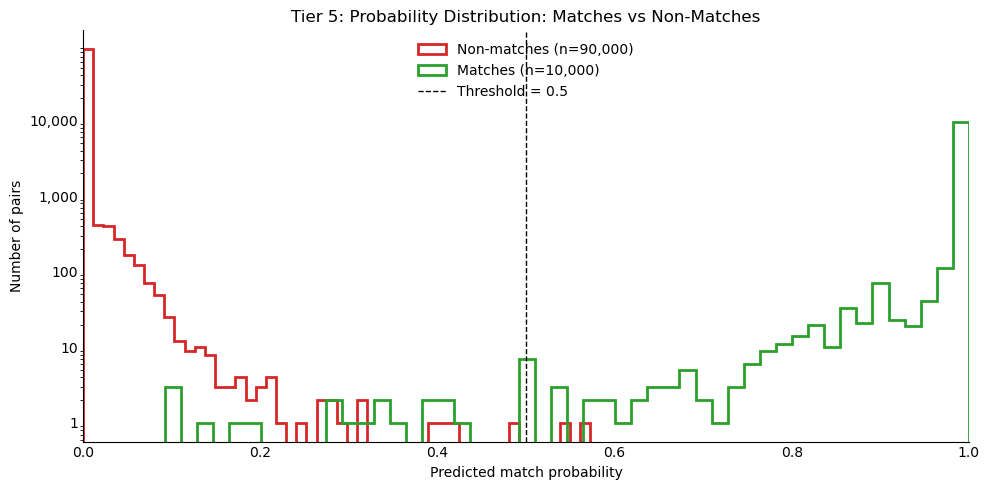

In [8]:
plot_score_distribution(
    match_scores     = test_candidates.loc[test_candidates['is_match'],  'match_probability'],
    non_match_scores = test_candidates.loc[~test_candidates['is_match'], 'match_probability'],
    threshold        = THRESHOLD,
    title            = 'Tier 5: Probability Distribution: Matches vs Non-Matches',
    x_label          = 'Predicted match probability',
    filename         = 'tier5_score_distribution.png',
)

## Save Results

In [9]:
save_metrics(metrics, 'tier5_metrics.csv')
save_example_pair_predictions(candidates, 'T5_federated_bloom', 'match_probability', 'tier5_example_predictions.csv')